# Trabajo Práctico — Matemática III
## Detección de Phishing mediante URLs con Red Neuronal

---
# Parte 1 — Análisis de la base de datos

### Instalación de librerías y carga de la base.

In [1]:
import subprocess
import sys
def install_all(packages):
    # Función que instala paquetes usando pip install.

    for package in packages:
        print(f"Installing {package}...")
        try:
            # Calls the pip module via the current python executable
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        except subprocess.CalledProcessError as e:
            print(f"Error al instalar el paquete: {package}: {e}")

my_packages = ["matplotlib", "kagglehub", "seaborn", "scikit-learn", "sympy"]
install_all(my_packages)

Installing matplotlib...
Installing kagglehub...
Installing seaborn...
Installing scikit-learn...
Installing sympy...


In [2]:
# Import de librerías.
import numpy as np
import random
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sympy import *
import time

# Ruta del archivo dentro del dataset de Kaggle.
file_path = "Dataset.csv"

# Carga link de Kaggle (extraído de la página).
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sahandnamvar/phishing-url-detection-111k-urls-22-features",
  file_path,
)

c:\Users\Ariana\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Ariana\AppData\Local\Temp\ipykernel_14144\3658897497.py:19: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


## (a) Descripción de columnas

In [3]:
# Total de filas x columnas.
print(f"Dimensiones originales: {df.shape}.")
#Imprimir las primeras 5 filas para observar tipo de datos.
df.head()

Dimensiones originales: (116600, 26).


,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [4]:
print(f"Estadísticas descriptivas de las columnas numéricas:")
# Redondear a 3 decimales.
df.describe().round(3)

Estadísticas descriptivas de las columnas numéricas:


,url_len,dom_len,is_ip,tld_len,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
count,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,...,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000,116600.000
mean,32.953,12.846,0.000,3.320,0.846,25.007,0.944,7.002,0.080,0.038,...,0.054,0.753,0.013,0.234,0.431,3.215,3.864,6.391,1.601,0.142
std,29.370,5.141,0.011,1.418,0.481,22.396,5.948,3.996,0.493,0.200,...,0.484,0.059,0.048,0.053,0.495,0.931,0.360,17.589,19.274,0.349
min,12.000,4.000,0.000,0.000,0.000,4.000,0.000,4.000,0.000,0.000,...,0.000,0.145,0.000,0.013,0.000,2.000,2.654,0.000,0.000,0.000
25%,22.000,9.000,0.000,2.000,1.000,16.000,0.000,6.000,0.000,0.000,...,0.000,0.714,0.000,0.194,0.000,3.000,3.642,1.000,0.000,0.000
50%,27.000,11.000,0.000,3.000,1.000,20.000,0.000,6.000,0.000,0.000,...,0.000,0.750,0.000,0.237,0.000,3.000,3.831,1.000,0.000,0.000
75%,34.000,16.000,0.000,3.000,1.000,27.000,0.000,7.000,0.000,0.000,...,0.000,0.793,0.000,0.273,1.000,3.000,4.027,4.000,0.000,0.000
max,1202.000,62.000,1.000,22.000,7.000,1037.000,321.000,234.000,29.000,17.000,...,20.000,0.936,0.826,0.524,1.000,37.000,6.033,670.000,1148.000,1.000


In [5]:
# Estructura y tipo de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  object 
 1   url_len       116600 non-null  int64  
 2   dom           116600 non-null  object 
 3   dom_len       116600 non-null  int64  
 4   is_ip         116600 non-null  int64  
 5   tld           116586 non-null  object 
 6   tld_len       116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digi

In [6]:
# Respuesta a pregunta a)
# Describir cada columna del conjunto de datos. ¿Qué representa?¿Es una variable categórica, numérica, etc?
descripcion = {
    "url":          ("Texto",       "URL completa"),
    "url_len":      ("Numérica",    "Longitud total de la URL en caracteres"),
    "dom":          ("Texto",       "Nombre del dominio principal"),
    "dom_len":      ("Numérica",    "Longitud del nombre de dominio"),
    "is_ip":        ("Binaria",     "1 si la URL usa IP en lugar de nombre de dominio"),
    "tld":          ("Categórica",  "Extensión del dominio"),
    "tld_len":      ("Numérica",    "Longitud de la extensión del dominio"),
    "subdom_cnt":   ("Numérica",    "Cantidad de subdominios"),
    "letter_cnt":   ("Numérica",    "Cantidad de letras en la URL"),
    "digit_cnt":    ("Numérica",    "Cantidad de dígitos numéricos en la URL"),
    "special_cnt":  ("Numérica",    "Cantidad de caracteres especiales"),
    "eq_cnt":       ("Numérica",    "Cantidad de signos igual (=)"),
    "qm_cnt":       ("Numérica",    "Cantidad de signos de interrogación (?)"),
    "amp_cnt":      ("Numérica",    "Cantidad de ampersands (&)"),
    "dot_cnt":      ("Numérica",    "Cantidad de puntos (.)"),
    "dash_cnt":     ("Numérica",    "Cantidad de guiones (-)"),
    "under_cnt":    ("Numérica",    "Cantidad de guiones bajos (_)"),
    "letter_ratio": ("Numérica",    "Cantidad de letras sobre el total de caracteres"),
    "digit_ratio":  ("Numérica",    "Cantidad de dígitos sobre el total de caracteres"),
    "spec_ratio":   ("Numérica",    "Cantidad de caracteres especiales sobre el total"),
    "is_https":     ("Binaria",     "1 si la URL usa protocolo seguro"),
    "slash_cnt":    ("Numérica",    "Cantidad de barras (/)"),
    "entropy":      ("Numérica",    "Entropía de Shannon"),
    "path_len":     ("Numérica",    "Longitud del path de la URL"),
    "query_len":    ("Numérica",    "Longitud de la query string"),
    "label":        ("Binaria",     "Variable objetivo: 0 = URL legítima, 1 = URL de phishing"),
}
# Impresión bonita.
df_desc = pd.DataFrame(descripcion, index=["Tipo","Descripción"]).T
df_desc.index.name = "Columna"
print(f"\nTotal de columnas: {len(descripcion)}.")
df_desc


Total de columnas: 26.


,Tipo,Descripción
Columna,,
url,Texto,URL completa
url_len,Numérica,Longitud total de la URL en caracteres
dom,Texto,Nombre del dominio principal
dom_len,Numérica,Longitud del nombre de dominio
is_ip,Binaria,1 si la URL usa IP en lugar de nombre de dominio
tld,Categórica,Extensión del dominio
tld_len,Numérica,Longitud de la extensión del dominio
subdom_cnt,Numérica,Cantidad de subdominios
letter_cnt,Numérica,Cantidad de letras en la URL


In [7]:
def calculate_label_percentage(dataframe):
    # Función que calcula e imprime la distribución de la variable objetivo (label) en el dataframe dado.
    print(f"Distribución de la variable objetivo (label):")
    #Contar e imprimir con que frecuencia aparecen los valores en label.
    counts = dataframe["label"].value_counts()
    # Impresión de resultados.
    print(f"  Legítimas (0): {counts[0]:,} ({counts[0]/len(dataframe)*100:.1f}%)")
    print(f"  Phishing  (1): {counts[1]:,} ({counts[1]/len(dataframe)*100:.1f}%)")
    print(f"  Total        : {len(dataframe):,}")

calculate_label_percentage(df)

Distribución de la variable objetivo (label):
  Legítimas (0): 100,000 (85.8%)
  Phishing  (1): 16,600 (14.2%)
  Total        : 116,600


## (b) Correlación con la variable objetivo

In [8]:
# Excluir valores no numéricos para la correlación.
numeric_cols = [c for c in df.columns if c not in ["url", "dom", "tld", "label"]]

# 1. dataframe de la variable filtrada + columna label.
# 2. Cálculo de correlación con la variable objetivo.
# 3. Exclusión de la correlación con sí misma.
# 4. Orden de mayor a menor. 
correlation = df[numeric_cols + ["label"]].corr()["label"].drop("label").sort_values(key=abs, ascending=False)

print(f"Correlación de Pearson con la variable objetivo (Label):")
# Otra impresión bonita.
for col, val in correlation.items():
    sign = "(+)" if val > 0 else "(-)"
    print(f"  {col:<15} {val:+.3f} {sign}")

Correlación de Pearson con la variable objetivo (Label):
  digit_ratio     +0.518 (+)
  entropy         +0.513 (+)
  is_https        +0.398 (+)
  spec_ratio      -0.385 (-)
  digit_cnt       +0.329 (+)
  url_len         +0.324 (+)
  letter_cnt      +0.301 (+)
  eq_cnt          +0.261 (+)
  path_len        +0.249 (+)
  dash_cnt        +0.248 (+)
  qm_cnt          +0.225 (+)
  amp_cnt         +0.225 (+)
  special_cnt     +0.203 (+)
  slash_cnt       +0.176 (+)
  query_len       +0.164 (+)
  under_cnt       +0.140 (+)
  dot_cnt         -0.120 (-)
  tld_len         -0.117 (-)
  subdom_cnt      -0.102 (-)
  dom_len         -0.079 (-)
  letter_ratio    -0.074 (-)
  is_ip           +0.012 (+)


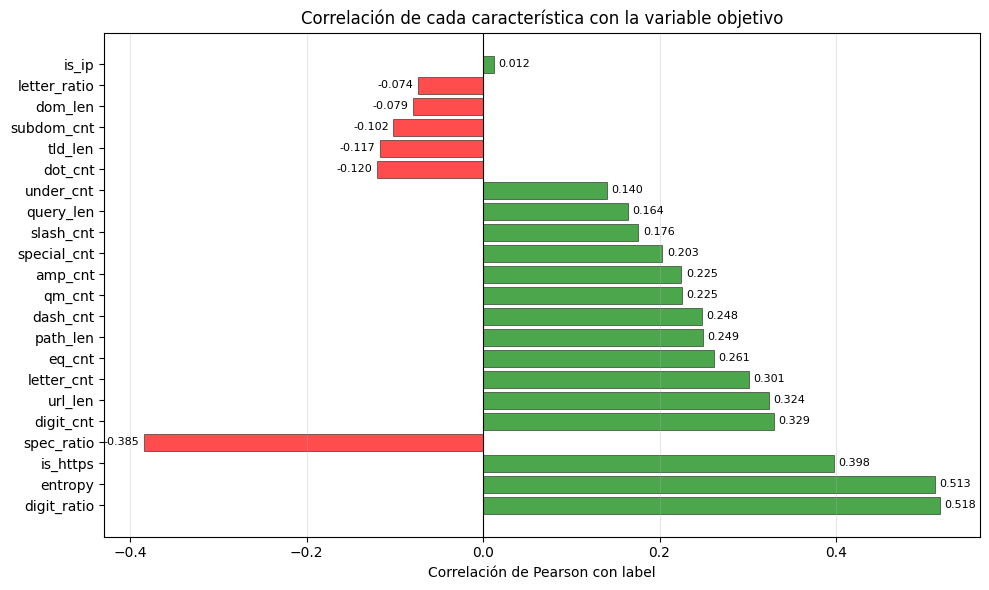

In [9]:
# Gráfico de correlación para mejor visualización (con ayuda de la ia)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["green" if v > 0 else "red" for v in correlation.values]
bars = ax.barh(correlation.index, correlation.values, color=colors, alpha=0.7, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con label")
ax.set_title("Correlación de cada característica con la variable objetivo")
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, correlation.values):
    ax.text(val + 0.005 if val >= 0 else val - 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig("correlacion_barras.png", bbox_inches="tight", dpi=120)
plt.show()

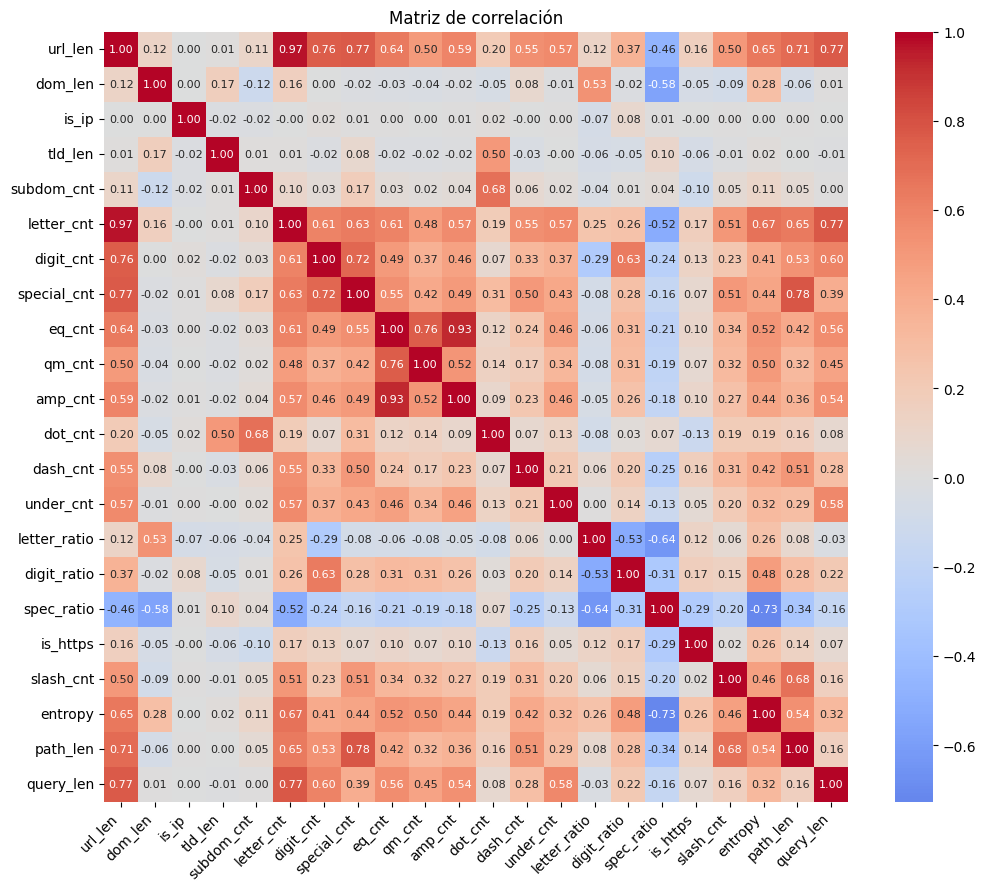

In [10]:
# Correlación entre todas las características. Sumo lo visto en clase.
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,            # Muestra los valores
    fmt=".2f",             # Dos decimales
    cmap="coolwarm",       # rojo = positivo, azul = negativo
    center=0,
    annot_kws={"size": 8}  # Tamaño de los valores
)

plt.xticks(rotation=45, ha="right")  #Rotación 45 y alineación a la derecha de etiquetas eje X 
plt.title("Matriz de correlación")
plt.savefig("correlacion_matrix.png", bbox_inches="tight", dpi=120)
plt.show()


## (c) ¿Es adecuada para clasificación binaria?

In [11]:
print("Análisis:")
print(f" - Variable objetivo binaria: label está dentro de {{0, 1}}.")
print(f" - Cantidad de registros: {len(df):,}.")
print(f" - Número de características numéricas: {len(numeric_cols)}.")
print(f" - Valores únicos en label: {df['label'].nunique()}.")
print()
print(f"Objetivo del modelo:")
print(f"  Predecir si una URL es de phishing (1) o legítima (0).")

Análisis:
 - Variable objetivo binaria: label está dentro de {0, 1}.
 - Cantidad de registros: 116,600.
 - Número de características numéricas: 22.
 - Valores únicos en label: 2.

Objetivo del modelo:
  Predecir si una URL es de phishing (1) o legítima (0).


## (d) Identificación y limpieza de datos atípicos

In [12]:
print("DIAGNÓSTICO DE DATOS A LIMPIAR")
print()

# 1. URLs duplicadas.
dupplicated_rows = df.duplicated().sum()
duplicated_url   = df.duplicated(subset=["url"]).sum()
print(f"1. Duplicados:")
print(f"  Filas duplicadas completas: {dupplicated_rows:,}.")
print(f"  Solo URLs duplicadas: {duplicated_url:,}.")
print()

# 2. Valores nulos.
print("2. Valores nulos por columna:")
rows_null = df.isnull().sum()[df.isnull().sum() > 0]
print(rows_null)
print()

# 3. Columnas binarias fuera de rango.
print("3. Valores binarios inválidos:")
binary_cols = ["is_ip", "is_https", "label"]
for col in binary_cols:
    # Verificar si hay inválidos (datos diferentes a 0 - 1).
    invalid = df[~df[col].isin([0, 1])]
    print(f"  {col}: {len(invalid)} valores fuera de {{0, 1}}.")

# 3.5 Columnas con valores negativos.
print("3.5. Columnas con valores negativos:")
count_cols = [
    "url_len", "dom_len", "tld_len", "subdom_cnt", "letter_cnt",
    "digit_cnt", "special_cnt", "eq_cnt", "qm_cnt", "amp_cnt",
    "dot_cnt", "dash_cnt", "under_cnt", "slash_cnt", "path_len", "query_len"
]

hay_negativos = False
for col in count_cols:
    negativos = (df[col] < 0).sum()

    if negativos > 0:
        hay_negativos = True
        print(f"  {col}: {negativos} valores negativos.")

if not hay_negativos:
    print("  No hay valores negativos en la base.")
print()

# 4. Columnas de Ratio dentro de 0 y 1.
print("4. Columnas de Ratio entre 0 y 1")
ratio_cols = ["letter_ratio", "digit_ratio", "spec_ratio"]
for col in ratio_cols:
    out_range = ((df[col] < 0) | (df[col] > 1)).sum()
    if out_range > 0:
        print(f"  {col}: {out_range} valores fuera de [0,1].")
    else:
        print(f"  {col}: OK (todos entre [0, 1]).")
print()

#PROBLEMA 1: 
#1369 FILAS COMPLETAMENTE DUPLICADAS

#PROBLEMA 2:
#14 FILAS CON VALORES TLD VACÍOS.

DIAGNÓSTICO DE DATOS A LIMPIAR

1. Duplicados:
  Filas duplicadas completas: 1,369.
  Solo URLs duplicadas: 1,369.

2. Valores nulos por columna:
tld    14
dtype: int64

3. Valores binarios inválidos:
  is_ip: 0 valores fuera de {0, 1}.
  is_https: 0 valores fuera de {0, 1}.
  label: 0 valores fuera de {0, 1}.
3.5. Columnas con valores negativos:
  No hay valores negativos en la base.

4. Columnas de Ratio entre 0 y 1
  letter_ratio: OK (todos entre [0, 1]).
  digit_ratio: OK (todos entre [0, 1]).
  spec_ratio: OK (todos entre [0, 1]).



In [13]:
print("CONSISTENCIA ENTRE DATOS")

# url_len debe coincidir con len(de la url)
df["_url_len_real"] = df["url"].str.len()
inconsistent_url = (df["url_len"] != df["_url_len_real"]).sum()
print(f"url_len vs len(url) inconsistentes: {inconsistent_url}.")

# dom_len debe coincidir con len(del dom)
df["_dom_len_real"] = df["dom"].str.len()
inconsistent_dom = (df["dom_len"] != df["_dom_len_real"]).sum()
print(f"dom_len vs len(dom) inconsistentes: {inconsistent_dom}.")

# tld_len debe coincidir con len(tld) (excluyendo los vacíos)
empty = df["tld"] == 0
df["_tld_len_real"] = df["tld"].str.len()
inconsistent_tld = (df.loc[empty, "tld_len"] != df.loc[empty, "_tld_len_real"]).sum()
print(f"tld_len vs len(tld) inconsistentes: {inconsistent_tld}.")

CONSISTENCIA ENTRE DATOS
url_len vs len(url) inconsistentes: 0.
dom_len vs len(dom) inconsistentes: 0.
tld_len vs len(tld) inconsistentes: 0.


IQR - Sin limpieza de datos

url_len    | Q1=22.00  Q3=34.00  IQR=12.00.
 - Límites=[4.00, 52.00].
 - Outliers: 9203 (7.89%).

dom_len    | Q1=9.00  Q3=16.00  IQR=7.00.
 - Límites=[-1.50, 26.50].
 - Outliers: 1994 (1.71%).

tld_len    | Q1=2.00  Q3=3.00  IQR=1.00.
 - Límites=[0.50, 4.50].
 - Outliers: 23655 (20.29%).

subdom_cnt | Q1=1.00  Q3=1.00  IQR=0.00.
 - Límites=[1.00, 1.00].
 - Outliers: 28421 (24.37%).

letter_cnt | Q1=16.00  Q3=27.00  IQR=11.00.
 - Límites=[-0.50, 43.50].
 - Outliers: 7777 (6.67%).

digit_cnt  | Q1=0.00  Q3=0.00  IQR=0.00.
 - Límites=[0.00, 0.00].
 - Outliers: 13824 (11.86%).

special_cnt | Q1=6.00  Q3=7.00  IQR=1.00.
 - Límites=[4.50, 8.50].
 - Outliers: 16432 (14.09%).

eq_cnt     | Q1=0.00  Q3=0.00  IQR=0.00.
 - Límites=[0.00, 0.00].
 - Outliers: 4581 (3.93%).

qm_cnt     | Q1=0.00  Q3=0.00  IQR=0.00.
 - Límites=[0.00, 0.00].
 - Outliers: 4421 (3.79%).

amp_cnt    | Q1=0.00  Q3=0.00  IQR=0.00.
 - Límites=[0.00, 0.00].
 - Outliers: 2172 (1.86%).

dot_cnt   

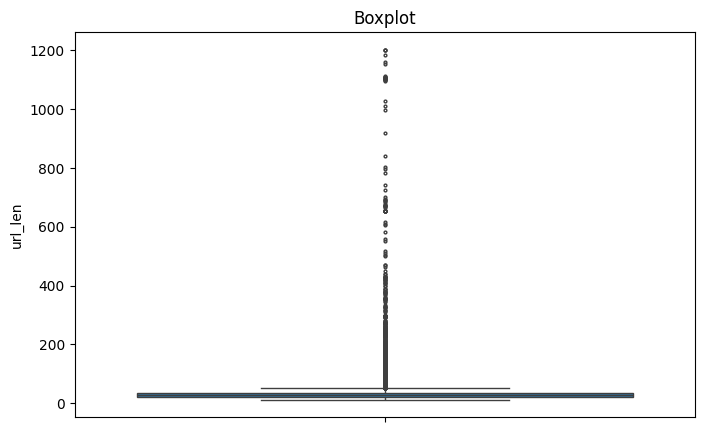

In [14]:
def boxplot(df, img_name):
    plt.figure(figsize=(8,5))
    sns.boxplot(y=df["url_len"], fliersize=2)
    plt.title("Boxplot")
    plt.savefig(img_name, bbox_inches="tight", dpi=120)
    plt.show()

def calculate_outliers_iqr(df, cols, verbose =True):
    # Función que calcula IRQ.
    outlier_report = {}

    for col in cols:
        # Cálculo de Quantiles.
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        # Cálculo de IRQ.
        IQR = Q3 - Q1

        # Cálculo rango intercuartílico inferior.
        lower = Q1 - 1.5 * IQR
        # Cálculo rango intercuartílico superior.
        upper = Q3 + 1.5 * IQR

        # Cálculo de datos fuera de los rangos.
        data_out_low  = (df[col] < lower).sum()
        data_out_high = (df[col] > upper).sum()
        data_out_total = data_out_low + data_out_high

        # Reporte de Outliers por columna.
        outlier_report[col] = {
            "Q1": Q1, "Q3": Q3, "IQR": IQR,
            "lower_bound": lower, "upper_bound": upper,
            "outliers_low": data_out_low,
            "outliers_high": data_out_high,
            "outliers_total": data_out_total,
            # Porcentaje de Outliers respecto al total de filas.
            "percentage": round(data_out_total / len(df) * 100, 2)
        }

        if verbose:
            print(f"{col:<10} | Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}.")
            print(f" - Límites=[{lower:.2f}, {upper:.2f}].")
            print(f" - Outliers: {data_out_total} ({outlier_report[col]['percentage']}%).\n")

    if verbose:
        boxplot(df, "boxplot_sin_limpieza")
    
    return outlier_report

iqr_cols = [
    "url_len", "dom_len", "tld_len", "subdom_cnt",
    "letter_cnt", "digit_cnt", "special_cnt", "eq_cnt",
    "qm_cnt", "amp_cnt", "dot_cnt", "dash_cnt", "under_cnt",
    "slash_cnt", "entropy", "path_len", "query_len",
]

print("IQR - Sin limpieza de datos")
print()
calculate_outliers_iqr(df, iqr_cols);


# PROBLEMA 3:
# dom_len con outliers.

In [15]:
# LIMPIEZA DE LA BASE
outlier_report = calculate_outliers_iqr(df, iqr_cols, False)
df_clean = df.copy()
df_original = len(df_clean)

print("LIMPIEZA\n")

# 1. Eliminar filas completas duplicadas
df_clean = df_clean.drop_duplicates(subset="url", keep="first")
print(f"Después de eliminar duplicados: {len(df_clean):,} filas (eliminadas: {df_original - len(df_clean)}).")

# 2. Reemplazar los valores nulos por "Unknown"
df_clean["tld"] = df_clean["tld"].fillna("unknown")
print("Valores de tld vacíos completos con 'unknown'.")

# 3. Modificar Outliers de url_len
hi = outlier_report["url_len"]["upper_bound"]
df_clean["url_len"] = df_clean["url_len"].clip(upper=hi)

print()
print(f"Filas totales eliminadas: {df_original - len(df_clean):,} ({(df_original - len(df_clean))/df_original*100:.2f}%).")
print(f"Filas conservadas: {len(df_clean):,}.")


LIMPIEZA

Después de eliminar duplicados: 115,231 filas (eliminadas: 1369).
Valores de tld vacíos completos con 'unknown'.

Filas totales eliminadas: 1,369 (1.17%).
Filas conservadas: 115,231.


LUEGO DE LA LIMPIEZA:
Distribución de la variable objetivo (label):
  Legítimas (0): 98,641 (85.6%)
  Phishing  (1): 16,590 (14.4%)
  Total        : 115,231

IQR - Actualizado
url_len    | Q1=22.00  Q3=34.00  IQR=12.00.
 - Límites=[4.00, 52.00].
 - Outliers: 0 (0.0%).

dom_len    | Q1=9.00  Q3=16.00  IQR=7.00.
 - Límites=[-1.50, 26.50].
 - Outliers: 1984 (1.72%).

tld_len    | Q1=2.00  Q3=3.00  IQR=1.00.
 - Límites=[0.50, 4.50].
 - Outliers: 23551 (20.44%).

subdom_cnt | Q1=1.00  Q3=1.00  IQR=0.00.
 - Límites=[1.00, 1.00].
 - Outliers: 28282 (24.54%).

letter_cnt | Q1=16.00  Q3=27.00  IQR=11.00.
 - Límites=[-0.50, 43.50].
 - Outliers: 7747 (6.72%).

digit_cnt  | Q1=0.00  Q3=0.00  IQR=0.00.
 - Límites=[0.00, 0.00].
 - Outliers: 13775 (11.95%).

special_cnt | Q1=6.00  Q3=7.00  IQR=1.00.
 - Límites=[4.50, 8.50].
 - Outliers: 16340 (14.18%).

eq_cnt     | Q1=0.00  Q3=0.00  IQR=0.00.
 - Límites=[0.00, 0.00].
 - Outliers: 4560 (3.96%).

qm_cnt     | Q1=0.00  Q3=0.00  IQR=0.00.
 - Límites=[0.

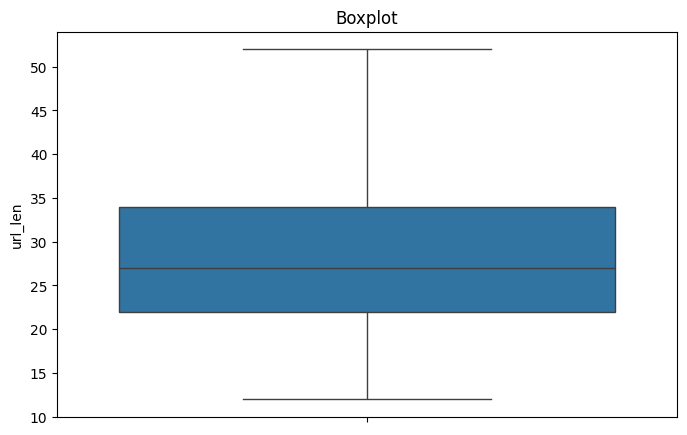

In [16]:
print("LUEGO DE LA LIMPIEZA:")
calculate_label_percentage(df_clean)
print()
print("IQR - Actualizado")
calculate_outliers_iqr(df_clean, iqr_cols);

## (e) Normalización

In [17]:
# Selección de columnas numéricas.
selected_cols = numeric_cols 
# 42 - random seed de misma división cada vez que se ejecuta el código.
SEED = 42
# X con columnas numéricas.
X = df_clean[selected_cols].values
# Y con variable objetivo.
y = df_clean["label"].values

# División train/test.
# 0.30 = 30% para testing.
# Stratify = Misma proporción de label en ambas particiones.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Impresiones con resultados.
print(f"Set de training: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Set de test:     {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
# Verificar distribuciones con impresiones.
print("Distribución de clases - Train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Clase {u}: {c:,} ({c/len(y_train)*100:.1f}%)")
print("Distribución de clases - Test:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Clase {u}: {c:,} ({c/len(y_test)*100:.1f}%)")

Set de training: 80,661 muestras (70%)
Set de test:     34,570 muestras (30%)

Distribución de clases - Train:
  Clase 0: 69,048 (85.6%)
  Clase 1: 11,613 (14.4%)
Distribución de clases - Test:
  Clase 0: 29,593 (85.6%)
  Clase 1: 4,977 (14.4%)


In [18]:
# Obtener mínimo por columna.
X_min   = X_train.min(axis=0)
# Calcular el rango = máximo - mínimo.
X_range = X_train.max(axis=0) - X_min
# Evitar dividir por 0.
X_range[X_range == 0] = 1
# Normalizar train - Todos entre 0 y 1.
X_train_norm = (X_train - X_min) / X_range
# Normalizar test con los min y max de train.
X_test_norm  = np.clip((X_test  - X_min) / X_range, 0, 1)

print("Verificación en train:")
print(f"  Min global: {X_train_norm.min():.2f}.")
print(f"  Max global: {X_train_norm.max():.2f}.")
print(f"  Min en test: {X_test_norm.min():.2f}.")
print(f"  Max en test: {X_test_norm.max():.2f}.")

# Clip test para mantener [0,1]
X_test_norm = np.clip(X_test_norm, 0, 1)

Verificación en train:
  Min global: 0.00.
  Max global: 1.00.
  Min en test: 0.00.
  Max en test: 1.00.


---
# Parte 2 — Red Neuronal

## (a) Arquitectura

In [19]:
print("Arquitectura")
number_input  = X_train_norm.shape[1]   # Cantidad de características
number_hidden = 16                      # Cantidad de neuronas en capa oculta
number_output = 1                       # Cantidad de salidas.

print(f"Capa de entrada: {number_input} neuronas - Características.")
print(f"Capa oculta: {number_hidden} neuronas  — activación: ReLU.")
print(f"Capa de salida: {number_output} neurona  — activación: Sigmoide.")
print()
print("Parámetros totales:")
print(f"W1: {number_input}×{number_hidden} = {number_input*number_hidden} pesos + {number_hidden} bias.")
print(f"W2: {number_hidden}×{number_output} = {number_hidden*number_output} pesos + {number_output} bias.")
print(f"Total: {number_input*number_hidden + number_hidden + number_hidden*number_output + number_output} parámetros.")

Arquitectura
Capa de entrada: 22 neuronas - Características.
Capa oculta: 16 neuronas  — activación: ReLU.
Capa de salida: 1 neurona  — activación: Sigmoide.

Parámetros totales:
W1: 22×16 = 352 pesos + 16 bias.
W2: 16×1 = 16 pesos + 1 bias.
Total: 385 parámetros.


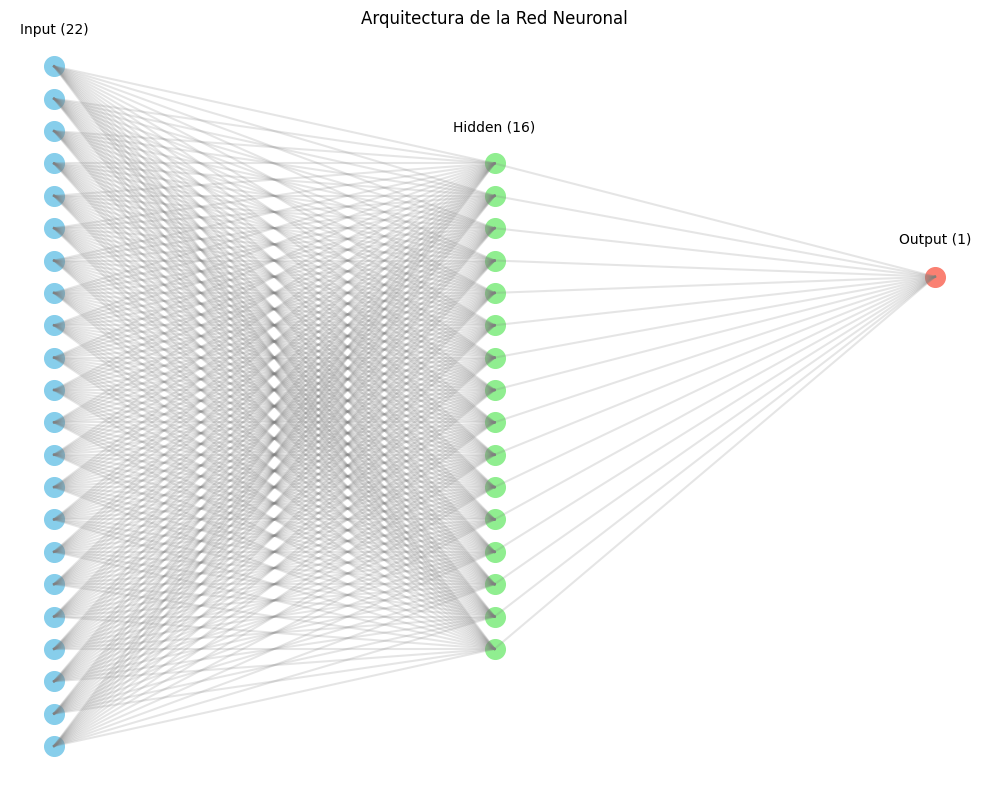

In [20]:
def dibujar_red(n_input, n_hidden):
    #Función que dibuja la arquitectura de la red neuronal.
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Posiciones en X
    x_input = 0
    x_hidden = 1
    x_output = 2

    # Generar posiciones en Y
    input_y = list(range(n_input))
    hidden_y = list(range(n_hidden))
    output_y = [n_hidden // 2]

    # Normalizar posiciones para centrar
    def normalize(y_list):
        max_y = max(y_list)
        return [y - max_y/2 for y in y_list]

    input_y = normalize(input_y)
    hidden_y = normalize(hidden_y)
    output_y = normalize(output_y)

    # Dibujar neuronas 
    for y in input_y:
        ax.scatter(x_input, y, s=200, color="skyblue")

    for y in hidden_y:
        ax.scatter(x_hidden, y, s=200, color="lightgreen")

    for y in output_y:
        ax.scatter(x_output, y, s=200, color="salmon")

    # Dibujar conexiones
    for y1 in input_y:
        for y2 in hidden_y:
            ax.plot([x_input, x_hidden], [y1, y2], color="gray", alpha=0.2)

    for y1 in hidden_y:
        for y2 in output_y:
            ax.plot([x_hidden, x_output], [y1, y2], color="gray", alpha=0.2)

    # Etiquetas
    ax.text(x_input, max(input_y)+1, "Input (22)", ha="center")
    ax.text(x_hidden, max(hidden_y)+1, "Hidden (16)", ha="center")
    ax.text(x_output, max(output_y)+1, "Output (1)", ha="center")

    ax.axis("off")
    plt.title("Arquitectura de la Red Neuronal")
    plt.tight_layout()
    plt.savefig("red_neuronal.png", dpi=300, bbox_inches="tight")
    #plt.show()

dibujar_red(22, 16)

## (b) Implementación con NumPy

In [21]:
# Entrada(22) → Capa Oculta (16, ReLU) → Salida (1, Sigmoide).
# Variables: Z1, A1, Z2, A2, W1, b1, W2, b2.
n_entrada = 22
n_oculta = 16
n_salida = 1

# Inicialización de pesos aleatorios con semilla fija.
rng = np.random.default_rng(SEED)
# 0 = distribución normal.
# np.sqrt(2.0 / n_entrada) = Deviación estandar - Previene que se desvanezcan datos.
# Matriz que corresponde con los valores dados Ej: (22, 16) para w1.
w1 = rng.normal(0, np.sqrt(2.0 / n_entrada), (n_entrada, n_oculta)) #(22, 16).
w2 = rng.normal(0, np.sqrt(1.0 / n_oculta),  (n_oculta,  n_salida)) #(16, 1).
# Inicializar sesgos en 0.
b1 = np.zeros((1, n_oculta)) # (1, 16).
b2 = np.zeros((1, n_salida)) # (1, 1).

# FORWARD
# Capa oculta: Z1 = X·W1 + b1  y  A1 = ReLU(Z1).
# Capa salida: Z2 = A1·W2 + b2 y  A2 = 1/(1+e^{-Z2}).
# A2 = y sombrerito = probabilidad de phishing.

# Función de activación ReLu.
def relu(Z):
    # Si Z < 0, 0.
    # Si Z > 0, queda igual.
    return np.maximum(0, Z)

# Función derivada de ReLu.
def relu_deriv(Z):
    return (Z > 0).astype(float)

# Función de Activación Sigmoide.
def sigmoid(Z):
    # 1 / (1 + e^{-Z})
    return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

# Función derivada de Sigmoide.
def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# Funcion que corre la red neuronal con los datos de entrada para predecir la salida
def forward(X):
    # Capa Oculta
    #Z1 = X . W1 + b1
    Z1 = X @ w1 + b1        
    # A1 = ReLU(Z1)
    A1 = relu(Z1)              

    # Capa Salida
    # Z2 = A1 . W2 + b2
    Z2 = A1 @ w2 + b2   
    # A2 = 1 / (1 + e^{-Z2})
    A2 = sigmoid(Z2)    

    return Z1, A1, Z2, A2

# Calculo de precisión
test_predictions = forward(X_test_norm)[3] # Solo A2

test_comparisons = np.equal(
    (test_predictions >= 0.5).flatten().astype(int),
    y_test
)

accuracy = accuracy_score(
    # aciertos/total.
    y_test,
    (test_predictions >= 0.5).astype(int)
) 

print(f"Precisión en test: {accuracy:.4f} ({test_comparisons.sum():,} aciertos de {len(y_test):,}).")

Precisión en test: 0.1438 (4,972 aciertos de 34,570).


In [22]:
# BACKPROPAGATION
# Función de costo (C = (A2 - y)^2).
# Paso 1: dC/dA2 = Derivada del costo respecto a A2.
# Paso 2: dA2/dZ2 = Derivada de sigmoide respecto a Z2.
# Paso 3: dZ2/dA1 = Derivada de Z2 respecto a A1 = W2.
# Paso 4: dZ2_dW2 = Derivada de Z2 respecto a W2 = A1.
# Paso 5: dZ2_dB2 = Derivada de Z2 respecto a B2 = 1.
# Paso 6: dA1_dZ1 = Derivada de A1 respecto de Z1. Z1 > 0.
# Paso 7: dZ1_dW1 = Derivada de Z1 respecto a W1 = X.
# Paso 8: dZ1_dB1 = Derivada de Z1 respecto a B1 = 1.
print("Back Propagation.")

W1, W2, B1, B2, A1, A2, Z1, Z2, X, Y = \
    symbols("W1 W2 B1 B2 A1 A2 Z1 Z2 X Y")

# Función del costo.
C = (A2 - Y)**2

#Paso 1.
# dC/dA2 = Derivada del costo respecto a A2 = 2*A2 - 2*Y.
dC_dA2 = diff(C, A2)
print("dC_dA2 = ", dC_dA2)

# Paso 2.
# dA2/dZ2 = Derivada de sigmoide respecto a Z2 .
_A2 = 1 / (1 + exp(-Z2))
dA2_dZ2 = diff(_A2, Z2) # exp(-Z2)/(1 + exp(-Z2))**2
print("dA2_dZ2 = ", dA2_dZ2)

# Paso 3.
# dZ2/dA1 = Derivada de Z2 respecto a A1 = W2.
_Z2 = A1*W2 + B2
dZ2_dA1 = diff(_Z2, A1)
print("dZ2_dA1 = ", dZ2_dA1) 

# Paso 4.
# dZ2_dW2 = Derivada de Z2 respecto a W2 = A1.
dZ2_dW2 = diff(_Z2, W2)
print("dZ2_dW2 = ", dZ2_dW2) 

# Paso 5.
# dZ2_dB2 = Derivada de Z2 respecto a B2 = 1.
dZ2_dB2 = diff(_Z2, B2)
print("dZ2_dB2 = ", dZ2_dB2) 

# Paso 6. 
# dA1_dZ1 = Derivada de A1 respecto de Z1.
func_relu = lambda x: Max(x, 0)
_A1 = func_relu(Z1)

d_relu = lambda x: x > 0 
dA1_dZ1 = d_relu(Z1)
print("dA1_dZ1 = ", dA1_dZ1) # Z1 > 0

# Paso 7.
# dZ1_dW1 = Derivada de Z1 respecto a W1 = X.
_Z1 = X*W1 + B1
dZ1_dW1 = diff(_Z1, W1)
print("dZ1_dW1 = ", dZ1_dW1) # X

# Paso 8.
# dZ1_dB1 = Derivada de Z1 respecto a B1 = 1.
dZ1_dB1 = diff(_Z1, B1)
print("dZ1_dB1 = ", dZ1_dB1) # 1


# Descenso por gradiente estocástico.
L = 0.05  # La tasa de aprendizaje
n = X_train.shape[0]
print(n)

# Derivada de las funcion ReLu.
d_relu = lambda x: x > 0

# Devuelve pendientes para pesos y sesgos usando la regla de la cadena
def backward_prop(Z1, A1, Z2, A2, X, Y):
    # Transformar array 
    Y = Y.reshape(-1, 1)
    # Tamaño del batch (subconjunto de datos a procesar en una sola iteración)
    m = X.shape[0]                          

    # Cross- entropy + sigmoide - simplificación
    dC_dZ2 = A2 - Y

    # Gradiente del costo con respecto al peso de dW2.
    dW2 = A1.T @ dC_dZ2 / m             
    dB2 = np.mean(dC_dZ2, axis=0, keepdims=True)

    # Costo con respecto a dA1
    dC_dA1 = dC_dZ2 @ w2.T
    # Costo con respecto a dZ1
    dC_dZ1 = dC_dA1 * relu_deriv(Z1)      

    dW1 = X.T @ dC_dZ1 / m             
    dB1 = np.mean(dC_dZ1, axis=0, keepdims=True)

    return dW1, dB1, dW2, dB2

Back Propagation.
dC_dA2 =  2*A2 - 2*Y
dA2_dZ2 =  exp(-Z2)/(1 + exp(-Z2))**2
dZ2_dA1 =  W2
dZ2_dW2 =  A1
dZ2_dB2 =  1
dA1_dZ1 =  Z1 > 0
dZ1_dW1 =  X
dZ1_dB1 =  1
80661


In [23]:
# Descenso por gradiente estocástico.
L = 0.05  # La tasa de aprendizaje
n = X_train.shape[0]
print("Número de muestras en train: ", n)
total_estimado = 2 * 60 + 18.7  # 138.7 segundos
print(f"Tiempo estimado para 100,000 iteraciones: {total_estimado:.1f} segundos.")
# Derivada de las funcion ReLu.
d_relu = lambda x: x > 0

# Devuelve pendientes para pesos y sesgos usando la regla de la cadena
def backward_prop(Z1, A1, Z2, A2, X, Y):
    # Transformar array 
    Y = Y.reshape(-1, 1)
    # Tamaño del batch (subconjunto de datos a procesar en una sola iteración)
    m = X.shape[0]                          

    # Cross- entropy + sigmoide - simplificación
    dC_dZ2 = A2 - Y

    # Gradiente del costo con respecto al peso de dW2.
    dW2 = A1.T @ dC_dZ2 / m             
    dB2 = np.mean(dC_dZ2, axis=0, keepdims=True)

    # Costo con respecto a dA1
    dC_dA1 = dC_dZ2 @ w2.T
    # Costo con respecto a dZ1
    dC_dZ1 = dC_dA1 * relu_deriv(Z1)      


    dW1 = X.T @ dC_dZ1 / m             
    dB1 = np.mean(dC_dZ1, axis=0, keepdims=True)

    return dW1, dB1, dW2, dB2

# Ejecutar descenso de gradiente
for i in range(100_000):
    # seleccionar aleatoriamente datos de entrenamiento
    idx = rng.choice(n, 1, replace=False)
    
    X_sample = X_train_norm[idx]
    Y_sample = y_train[idx].reshape(-1,1)

    # pasar datos seleccionados aleatoriamente a través de la red neuronal
    Z1, A1, Z2, A2 = forward(X_sample)

    # distribuir error a través de la retropropagación
    # y devolver pendientes para pesos y sesgos
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    # Actualizar pesos y sesgos
    w1 -= L * dW1
    b1 -= L * dB1
    w2 -= L * dW2
    b2 -= L * dB2

    # Mostrar avance cada 5000 iteraciones
    if (i+1) % 5000 == 0:
        test_predictions = forward(X_test_norm)[3] # Solo A2
        accuracy = accuracy_score(
            y_test,
            (test_predictions >= 0.5).astype(int)
        ) 
        tiempo_restante = total_estimado - (i+1) * (total_estimado / 100000)
        print(f"Ejecutando Iteración {i+1:6d}/100000 | Tiempo restante: {tiempo_restante:.1f} s")


Número de muestras en train:  80661
Tiempo estimado para 100,000 iteraciones: 138.7 segundos.
Ejecutando Iteración   5000/100000 | Tiempo restante: 131.8 s
Ejecutando Iteración  10000/100000 | Tiempo restante: 124.8 s
Ejecutando Iteración  15000/100000 | Tiempo restante: 117.9 s
Ejecutando Iteración  20000/100000 | Tiempo restante: 111.0 s
Ejecutando Iteración  25000/100000 | Tiempo restante: 104.0 s
Ejecutando Iteración  30000/100000 | Tiempo restante: 97.1 s
Ejecutando Iteración  35000/100000 | Tiempo restante: 90.2 s
Ejecutando Iteración  40000/100000 | Tiempo restante: 83.2 s
Ejecutando Iteración  45000/100000 | Tiempo restante: 76.3 s
Ejecutando Iteración  50000/100000 | Tiempo restante: 69.3 s
Ejecutando Iteración  55000/100000 | Tiempo restante: 62.4 s
Ejecutando Iteración  60000/100000 | Tiempo restante: 55.5 s
Ejecutando Iteración  65000/100000 | Tiempo restante: 48.5 s
Ejecutando Iteración  70000/100000 | Tiempo restante: 41.6 s
Ejecutando Iteración  75000/100000 | Tiempo res

## (c) Entrenamiento y Curvas.

In [24]:
# Iniciar pesos
rng = np.random.default_rng(SEED)
w1 = rng.normal(0, np.sqrt(2.0 / n_entrada), (n_entrada, n_oculta)) #(22, 16).
w2 = rng.normal(0, np.sqrt(1.0 / n_oculta),  (n_oculta,  n_salida)) #(16, 1).
b1 = np.zeros((1, n_oculta))
b2 = np.zeros((1, n_salida))

# Tasa de aprendizaje.
L = 0.05
# Ciclo de entrenamiento.
epochs = 25000
# Número de training samples.
batch_size = 64

train_loss, test_loss = [], []
train_acc,  test_acc  = [], []

for epoch in range(epochs):
    # Número total de samples, batch size, cada index se elige sin reemplazo. 
    idx = rng.choice(X_train_norm.shape[0], batch_size, replace=False)

    # Selección aleatoria de un batch de datos de entrenamiento.
    X_sample = X_train_norm[idx]    
    # Transformar Y_sample a formato columna.      
    Y_sample = y_train[idx].reshape(-1, 1)

    # Ejecución del Forward
    Z1, A1, Z2, A2 = forward(X_sample)
    # Ejecución del backward.
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    # Actualización.
    w1 -= L * dW1
    b1 -= L * dB1
    w2 -= L * dW2
    b2 -= L * dB2

    # Evaluar sobre datos normalizados
    _, _, _, A2_tr = forward(X_train_norm)
    _, _, _, A2_te = forward(X_test_norm)

    def cross_entropy(y_real, y_pred):
        # Función de pérdida.
        # Se clippean las predicciones para evitar log(0) o log(1).
        y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
        
        # Devuelve el promedio de la función de pérdida.
        return -np.mean(
        y_real * np.log(y_pred) +
        (1 - y_real) * np.log(1 - y_pred)
    )

    def accuracy(y_real, y_pred):
        # Función de precisión (accuracy).
        pred = (y_pred >= 0.5).astype(int)
        # Devuelve el promedio de aciertos.
        return np.mean(pred == y_real)
    
    # Cálculo de pérdida y precisión para train y test.
    l_tr = cross_entropy(y_train, A2_tr.flatten())
    l_te = cross_entropy(y_test, A2_te.flatten())

    # Cálculo de precisión para train y test.
    acc_tr = accuracy(y_train, A2_tr.flatten())
    acc_te = accuracy(y_test, A2_te.flatten())

    # Almacenar resultados.
    train_loss.append(l_tr); 
    test_loss.append(l_te);
    train_acc.append(acc_tr); 
    test_acc.append(acc_te) 
    # Imprimir cada 100 epochs.
    if epoch % 100 == 0: 
        print(f"Epoch {epoch:4d} | loss={l_tr:.4f} | acc={acc_tr:.4f} | " 
            f"val_loss={l_te:.4f} | val_acc={acc_te:.4f}")
        

Epoch    0 | loss=0.7748 | acc=0.1433 | val_loss=0.7749 | val_acc=0.1432
Epoch  100 | loss=0.4107 | acc=0.8560 | val_loss=0.4106 | val_acc=0.8560
Epoch  200 | loss=0.3670 | acc=0.8560 | val_loss=0.3667 | val_acc=0.8560
Epoch  300 | loss=0.3307 | acc=0.8560 | val_loss=0.3302 | val_acc=0.8560
Epoch  400 | loss=0.3014 | acc=0.8560 | val_loss=0.3006 | val_acc=0.8560
Epoch  500 | loss=0.2814 | acc=0.8690 | val_loss=0.2804 | val_acc=0.8694
Epoch  600 | loss=0.2659 | acc=0.8870 | val_loss=0.2646 | val_acc=0.8879
Epoch  700 | loss=0.2547 | acc=0.8920 | val_loss=0.2532 | val_acc=0.8932
Epoch  800 | loss=0.2460 | acc=0.8914 | val_loss=0.2443 | val_acc=0.8928
Epoch  900 | loss=0.2397 | acc=0.8903 | val_loss=0.2380 | val_acc=0.8912
Epoch 1000 | loss=0.2359 | acc=0.8905 | val_loss=0.2340 | val_acc=0.8915
Epoch 1100 | loss=0.2306 | acc=0.8901 | val_loss=0.2286 | val_acc=0.8917
Epoch 1200 | loss=0.2279 | acc=0.8906 | val_loss=0.2259 | val_acc=0.8920
Epoch 1300 | loss=0.2246 | acc=0.8918 | val_loss=0.

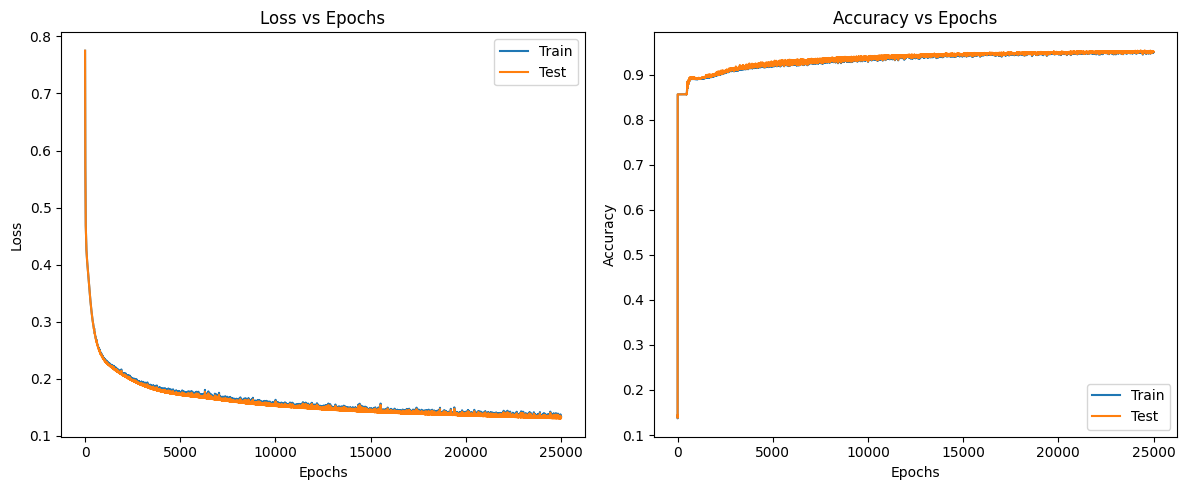

In [25]:
# Gráficos.
plt.figure(figsize=(12,5))

# Loss vs Epochs.
plt.subplot(1,2,1)
plt.plot(train_loss, label="Train")
plt.plot(test_loss, label="Test")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy vs Epochs.
plt.subplot(1,2,2)
plt.plot(train_acc, label="Train")
plt.plot(test_acc, label="Test")
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("vs.png", bbox_inches="tight", dpi=120)
plt.show()

In [26]:
print("Análisis de Overfitting.")
print()

# Promediar las últimas 100 epoch
final_train_loss = np.mean(train_loss[-100:])
final_test_loss  = np.mean(test_loss[-100:])
final_train_acc  = np.mean(train_acc[-100:])
final_test_acc   = np.mean(test_acc[-100:])

print("Loss.")
print(f"Train: {final_train_loss:.4f} | Test: {final_test_loss:.4f} | Diferencia: {abs(final_test_loss - final_train_loss):.4f}")
print("Accuracy.")
print(f"Train: {final_train_acc:.4f} | Test: {final_test_acc:.4f} | Diferencia: {abs(final_test_acc  - final_train_acc):.4f}")
print()

gap_loss = final_test_loss - final_train_loss
print(f"Gap Loss: {gap_loss:.4f}")

Análisis de Overfitting.

Loss.
Train: 0.1336 | Test: 0.1314 | Diferencia: 0.0022
Accuracy.
Train: 0.9499 | Test: 0.9512 | Diferencia: 0.0014

Gap Loss: -0.0022


---
# Parte 3 — Comparación con scikit-learn

## (a) Implementación con scikit-learn

In [27]:
# Entrada: 22 features
# Capa oculta: 16 neuronas — activación ReLU
# Salida: 1 neurona — activación Sigmoide
# Learning rate=0.05, batch_size=64, max_iter=25000, descenso de gradiente estocástico
nn_sklearn = MLPClassifier(
    hidden_layer_sizes=(16,),      # 1 capa oculta con 16 neuronas
    activation="relu",             # ReLU en capa oculta
    solver="sgd",                  # descenso de gradiente estocástico
    learning_rate_init=0.05,       # learning rate
    batch_size=64,                 # mini-batch 
    max_iter=25000,                 # iteraciones
    random_state=SEED              # semilla para reproducibilidad
)

# Entrenamiento de la red.
nn_sklearn.fit(X_train_norm, y_train)

# Train Accuracy
skit_train_acc = nn_sklearn.score(X_train_norm, y_train)
# Test Acurracy.
skit_test_acc  = nn_sklearn.score(X_test_norm,  y_test)
print("Scikit-Learn")
print()
print(f"Accuracy Train: {skit_train_acc:.4f}")
print(f"Accuracy Test:  {skit_test_acc:.4f}")


Scikit-Learn

Accuracy Train: 0.9710
Accuracy Test:  0.9720


## (b) Comparación NumPy vs scikit-learn

In [28]:
# Resultados Numpy.
# A2_train_np = Probabilidades de phishing para el set de entrenamiento.
_, _, _, A2_train_np = forward(X_train_norm)
# A2_test_np = Probabilidades de phishing para el set de test.
_, _, _, A2_test_np  = forward(X_test_norm)
# Redondeo + conversión a boolean con comparación.
y_pred_np_train = (A2_train_np.flatten() >= 0.5).astype(int)
y_pred_np_test  = (A2_test_np.flatten()  >= 0.5).astype(int)

# Cálculo de acurracy para train y test.
np_train_acc = accuracy_score(y_train, y_pred_np_train)
np_test_acc  = accuracy_score(y_test,  y_pred_np_test)

print()
print(f"{"Acurracy":<10} {"NumPy":>10}  {"sklearn":>10}")
print(f"{"-" * 35}")
print(f"{'Train':<10} {np_train_acc:>10.4f}  {skit_train_acc:>10.4f}")
print(f"{'Test':<10} {np_test_acc:>10.4f}  {skit_test_acc:>10.4f}")
print()
# Diferencia de acurracy en test.
diff_acc = abs(np_test_acc - skit_test_acc)
print(f"Diferencia de accuracy en test: {diff_acc:.4f}")


Acurracy        NumPy     sklearn
-----------------------------------
Train          0.9497      0.9710
Test           0.9510      0.9720

Diferencia de accuracy en test: 0.0210


In [29]:
from sklearn.metrics import classification_report

print("=== Red NumPy ===")
print(classification_report(y_test, y_pred_np_test))

print("\n=== Red Scikit-Learn ===")
y_pred_sklearn = nn_sklearn.predict(X_test_norm)
print(classification_report(y_test, y_pred_sklearn))

=== Red NumPy ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     29593
           1       0.87      0.77      0.82      4977

    accuracy                           0.95     34570
   macro avg       0.92      0.88      0.90     34570
weighted avg       0.95      0.95      0.95     34570


=== Red Scikit-Learn ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     29593
           1       0.92      0.88      0.90      4977

    accuracy                           0.97     34570
   macro avg       0.95      0.93      0.94     34570
weighted avg       0.97      0.97      0.97     34570



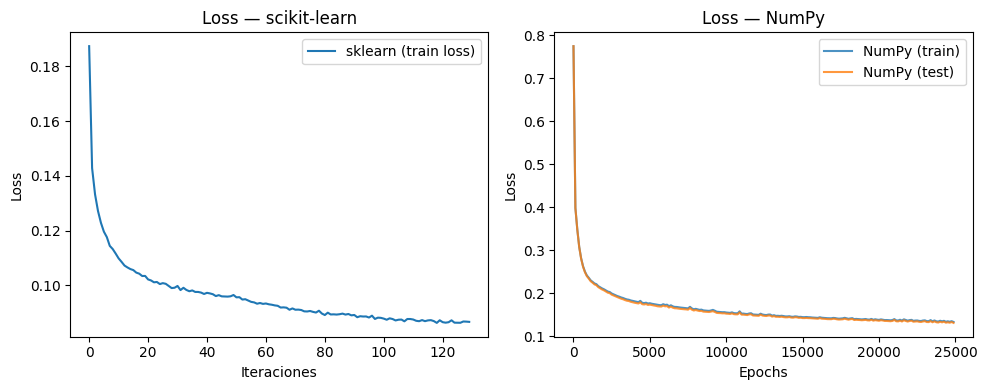

In [30]:
# Curva de de scikit-learn
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(nn_sklearn.loss_curve_, label="sklearn (train loss)")
plt.title("Loss — scikit-learn")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
# Curva NumPy 
epochs_np = list(range(0, len(train_loss), max(1, len(train_loss)//200)))
plt.plot(epochs_np, [train_loss[i] for i in epochs_np], label="NumPy (train)", alpha=0.8)
plt.plot(epochs_np, [test_loss[i]  for i in epochs_np], label="NumPy (test)",  alpha=0.8)
plt.title("Loss — NumPy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("numpy_vs_scikit.png", bbox_inches="tight", dpi=120)
plt.show()

## (c) Exploración de arquitecturas alternativas

In [31]:
print("Arquitecturas Alternativas")

arquitecturas = {
    "A1 - Original (16,)":        (16,),
    "A2 - Dos capas (32, 16)":    (32, 16),
    "A3 - Tres capas (64,32,16)": (64, 32, 16),
}

resultados = {}

for nombre, capas in arquitecturas.items():
    testingAlt = MLPClassifier(
        hidden_layer_sizes=capas,
        activation="relu",
        solver="sgd",
        learning_rate_init=0.05,
        batch_size=64,
        max_iter=200,
        random_state=SEED
    )
  
    # Entrenamiento de la red.
    testingAlt.fit(X_train_norm, y_train)
 
    # Evaluación en test.
    y_pred_alt = testingAlt.predict(X_test_norm)
    # Cálculo de acurracy para test.
    acc_alt    = accuracy_score(y_test, y_pred_alt)
    # Cálculo de parámetros totales: pesos + sesgos.
    n_params = sum(w.size for w in testingAlt.coefs_) + sum(b.size for b in testingAlt.intercepts_)
    
    resultados[nombre] = {
        "Capas": str(capas),
        "acc_train": testingAlt.score(X_train_norm, y_train),
        "acc_test":  acc_alt,
        "n_params": n_params
    }
    print(f"{nombre}: Acurracy Test = {acc_alt:.5f}")


Arquitecturas Alternativas
A1 - Original (16,): Acurracy Test = 0.97200
A2 - Dos capas (32, 16): Acurracy Test = 0.97576
A3 - Tres capas (64,32,16): Acurracy Test = 0.97622


In [32]:
# Imprimir resultados.
nombres   = list(resultados.keys())
# Listas de acurracy para train y test.
acc_train = [resultados[n]["acc_train"] for n in nombres]
acc_test  = [resultados[n]["acc_test"]  for n in nombres]

print(f"{"Arquitectura":<30} {"Parámetros":12}")
print(f"{"-" * 45}")
for n in nombres:
    r = resultados[n]
    print(f"{n:<30} {r["acc_test"]:12}")


Arquitectura                   Parámetros  
---------------------------------------------
A1 - Original (16,)            0.9719988429273937
A2 - Dos capas (32, 16)        0.9757593288978883
A3 - Tres capas (64,32,16)     0.9762221579404108
